In [2]:
import os
import cv2
import time
import pydicom
import numpy as np
import pandas as pd
from scipy.io import loadmat
import matplotlib.pyplot as plt

# Show final Results

In [3]:
def show_results(images: list, titles: list):
    plt.figure(figsize=(12, 4))
    for i in range(3):
        plt.subplot(1, 3, i + 1)
        plt.imshow(images[i], cmap='gray')
        plt.title(titles[i])
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Question2: Read a PPM file

In [4]:
def read_ppm(path):
    with open(path, 'rb') as f:
        header_line = f.readline().strip()
        header_line = header_line.split()
        if header_line[0] != b'P6':
            return -1, -1, -1, -1

        header_tokens = list(map(int, header_line[1:]))
        width, height, maxval = header_tokens

        img_data = f.read(width * height * 3)

        img = np.frombuffer(img_data, dtype=np.uint8).reshape((height, width, 3))
        return img, width, height, maxval

<Figure size 1200x400 with 0 Axes>

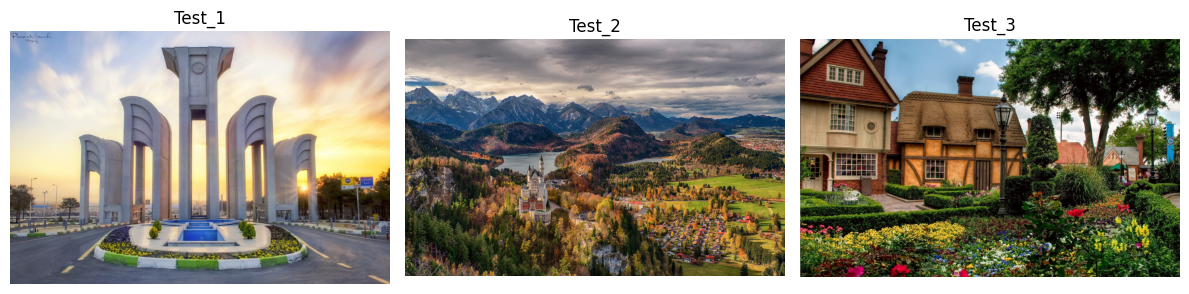

In [5]:
ppm_img1, _, _, _ = read_ppm('data/Q2/Test_1.ppm')
ppm_img2, _, _, _ = read_ppm('data/Q2/Test_2.ppm')
ppm_img3, _, _, _ = read_ppm('data/Q2/Test_3.ppm')


plt.figure(figsize=(12, 4))

titles = ['Test_1', 'Test_2', 'Test_3']
images = [ppm_img1, ppm_img2, ppm_img3]
show_results(images, titles)

# Question3: MSE For images

In [6]:
def my_mse(image1: np.ndarray, image2: np.ndarray):
    if image1.shape != image2.shape:
        return -1

    img1_flat = image1.flatten()
    img2_flat = image2.flatten()


    error = img1_flat - img2_flat
    error_square = error ** 2
    error_square_sum = np.sum(error_square)
    mean_error_square_sum = error_square_sum / len(img1_flat)
    return mean_error_square_sum

## Evaluation of MSE

In [7]:
img1 = cv2.imread('data/Q2/Test_2.ppm', cv2.IMREAD_COLOR)
img2 = cv2.imread('data/Q2/Test_2.ppm', cv2.IMREAD_COLOR)

my_mse(img1, img2)

0.0

In [8]:
white_image = np.zeros((255, 255)) + 255
black_image = np.zeros((255, 255))

my_mse(white_image, black_image)

65025.0

# Question4: PSNR

In [9]:
def next_power_of_two(x):
    return 1 << (x - 1).bit_length()

def my_psnr(image1: np.ndarray, image2: np.ndarray):
    if image1.shape != image2.shape:
        return -1

    max_intensity = max(image1.max(), image2.max())

    next_pow2 = next_power_of_two(int(max_intensity + 1))
    max_value = next_pow2 - 1
    max_value_sq = max_value ** 2

    mse = np.mean((image1.astype(np.float64) - image2.astype(np.float64)) ** 2)

    if mse == 0:
        return np.inf

    return 10 * np.log10(max_value_sq / mse)

## Evaluation of PSNR

In [10]:
img1 = cv2.imread('data/Q2/Test_2.ppm', cv2.IMREAD_COLOR)
img2 = cv2.imread('data/Q2/Test_2.ppm', cv2.IMREAD_COLOR)

my_psnr(img1, img2)

inf

In [11]:
white_image = np.zeros((255, 255)) + 255
black_image = np.zeros((255, 255))

my_psnr(white_image, black_image)

0.0

# Question5: rgb2gray

## MSE between gray & color Image

In [12]:
def mse_gray_color(rgb_image: np.ndarray, gray_image: np.ndarray):
    gray_3d = np.repeat(gray_image[:, :, np.newaxis], 3, axis=2)
    return my_mse(rgb_image, gray_3d)

## Method 1: Average the channels

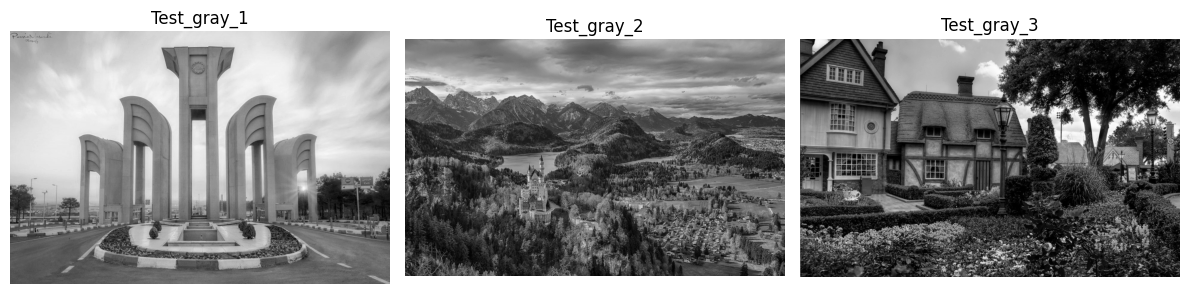

In [13]:
def rgb_to_gray_average(image: np.ndarray):
    gray_img = (image[:,:,0]/3) + (image[:,:,1]/3) + (image[:,:,2]/3)
    return gray_img


test1, _, _, _ = read_ppm('data/Q2/Test_1.ppm')
test2, _, _, _ = read_ppm('data/Q2/Test_2.ppm')
test3, _, _, _ = read_ppm('data/Q2/Test_3.ppm')

test1_gray_avg = rgb_to_gray_average(test1)
test2_gray_avg = rgb_to_gray_average(test2)
test3_gray_avg = rgb_to_gray_average(test3)

titles = ['Test_gray_1', 'Test_gray_2', 'Test_gray_3']
images = [test1_gray_avg, test2_gray_avg, test3_gray_avg]
show_results(images, titles)

## Method 2: luminance perception

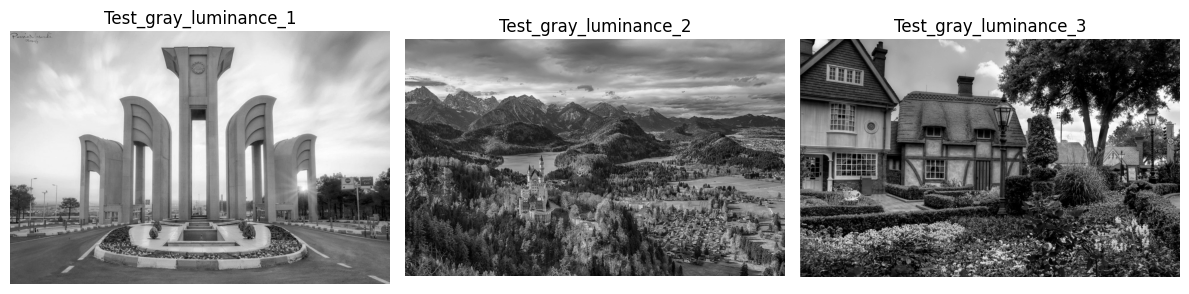

In [14]:
def rgb_to_gray_luminance(image):
    image = image / 255
    red_channel = image[:,:, 0]
    green_channel = image[:,:, 1]
    blue_channel = image[:,:, 2]

    final_gray = (0.2126 * red_channel) + (0.7152 * green_channel) + (0.0722 * blue_channel)
    final_gray = final_gray * 255
    return final_gray

test1_gray_lum = rgb_to_gray_luminance(test1)
test2_gray_lum = rgb_to_gray_luminance(test2)
test3_gray_lum = rgb_to_gray_luminance(test3)

titles = ['Test_gray_luminance_1', 'Test_gray_luminance_2', 'Test_gray_luminance_3']
images = [test1_gray_lum, test2_gray_lum, test3_gray_lum]
show_results(images, titles)

## Method 3: Linear approximation of gamma

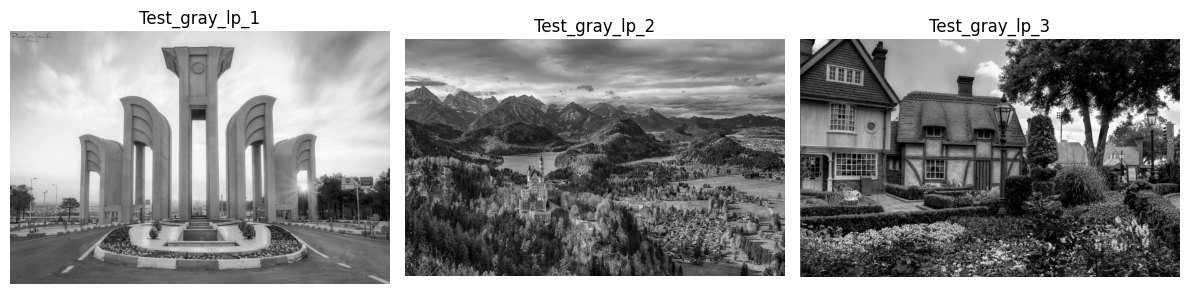

In [15]:
def rgb_to_gray_linear_approximation(image):
    image = image / 255
    red_channel = image[:,:, 0]
    green_channel = image[:,:, 1]
    blue_channel = image[:,:, 2]

    final_gray = (0.299 * red_channel) + (0.587 * green_channel) + (0.114 * blue_channel)
    final_gray = final_gray * 255
    return final_gray

test1_gray_lp = rgb_to_gray_linear_approximation(test1)
test2_gray_lp = rgb_to_gray_linear_approximation(test2)
test3_gray_lp = rgb_to_gray_linear_approximation(test3)

titles = ['Test_gray_lp_1', 'Test_gray_lp_2', 'Test_gray_lp_3']
images = [test1_gray_lp, test2_gray_lp, test3_gray_lp]
show_results(images, titles)

# Question 6: rgb2gray with minimum MSE

## Evaluation of Different rgb2gray Methods

In [16]:
test1, _, _, _ = read_ppm('data/Q2/Test_1.ppm')
test2, _, _, _ = read_ppm('data/Q2/Test_2.ppm')
test3, _, _, _ = read_ppm('data/Q2/Test_3.ppm')

test_list = [test1, test2, test3]
result_table = []

In [17]:
avg_result_list = [test1_gray_avg, test2_gray_avg, test3_gray_avg]
for i, avg_image in enumerate(avg_result_list):
    rgb_image = test_list[i]
    mse = mse_gray_color(rgb_image, avg_image)
    result_table.append({'Test': f'Test_{i}.ppm', 'Method': 'Average', 'Weights': [0.3333, 0.3333, 0.3333], 'MSE':mse})

In [18]:
lum_result_list = [test1_gray_lum, test2_gray_lum, test3_gray_lum]
for i, lum_image in enumerate(lum_result_list):
    rgb_image = test_list[i]
    mse = mse_gray_color(rgb_image, lum_image)
    result_table.append({'Test': f'Test_{i}.ppm', 'Method': 'LUM', 'Weights': [0.2126, 0.7152, 0.0722], 'MSE':mse})

In [19]:
lp_result_list = [test1_gray_lp, test2_gray_lp, test3_gray_lp]
for i, lp_image in enumerate(lp_result_list):
    rgb_image = test_list[i]
    mse = mse_gray_color(rgb_image, lp_image)
    result_table.append({'Test': f'Test_{i}.ppm', 'Method': 'Linear Approximation', 'Weights': [0.2990, 0.5870, 0.1140], 'MSE':mse})

In [20]:
result_table = pd.DataFrame(result_table)
result_table

,Test,Method,Weights,MSE
0,Test_0.ppm,Average,"[0.3333, 0.3333, 0.3333]",406.507205
1,Test_1.ppm,Average,"[0.3333, 0.3333, 0.3333]",515.603866
2,Test_2.ppm,Average,"[0.3333, 0.3333, 0.3333]",632.527341
3,Test_0.ppm,LUM,"[0.2126, 0.7152, 0.0722]",472.955072
4,Test_1.ppm,LUM,"[0.2126, 0.7152, 0.0722]",575.935576
5,Test_2.ppm,LUM,"[0.2126, 0.7152, 0.0722]",746.212540
6,Test_0.ppm,Linear Approximation,"[0.299, 0.587, 0.114]",460.720007
7,Test_1.ppm,Linear Approximation,"[0.299, 0.587, 0.114]",567.399317
8,Test_2.ppm,Linear Approximation,"[0.299, 0.587, 0.114]",707.560469


In [21]:
final_result = pd.DataFrame([{'Method': 'Average', 'Mean MSE': result_table[:2]['MSE'].mean()},
                             {'Method': 'LUM', 'Mean MSE': result_table[3:5]['MSE'].mean()},
                             {'Method': 'Linear Approximation', 'Mean MSE': result_table[6:8]['MSE'].mean()}])
final_result

,Method,Mean MSE
0,Average,461.055536
1,LUM,524.445324
2,Linear Approximation,514.059662


# Question 7: Entropy implementation

In [22]:
def my_entropy(image_name: str):
    if image_name.lower().endswith(".dcm"):
        ds = pydicom.dcmread(image_name)
        img = ds.pixel_array

    elif image_name.lower().endswith(".mat"):
        mat_data = loadmat(image_name)
        keys = [k for k in mat_data.keys() if not k.startswith("__")]
        img = mat_data[keys[0]]

    else:
        img = cv2.imread(image_name, cv2.IMREAD_UNCHANGED)

    arr = img.reshape(-1)

    counts = np.bincount(arr)
    p = counts[counts > 0] / len(arr)
    entropy = -np.sum(p * np.log2(p))

    return entropy

## Check Entropy on test images

In [23]:
exe_table = []
test_images = ['data/Q7/Cells.tif','data/Q7/Pavia.mat',
              'data/Q7/MRI/IM000001.dcm', 'data/Q7/MRI/IM000002.dcm', 'data/Q7/MRI/IM000003.dcm', 'data/Q7/MRI/IM000004.dcm',
              'data/Q7/MRI/IM000005.dcm', 'data/Q7/MRI/IM000006.dcm', 'data/Q7/MRI/IM000007.dcm', 'data/Q7/MRI/IM000008.dcm',
              'data/Q7/MRI/IM000009.dcm', 'data/Q7/MRI/IM000010.dcm', 'data/Q7/MRI/IM000011.dcm', 'data/Q7/MRI/IM000012.dcm',
              'data/Q7/MRI/IM000013.dcm', 'data/Q7/MRI/IM000014.dcm', 'data/Q7/MRI/IM000015.dcm', 'data/Q7/MRI/IM000016.dcm',
              'data/Q7/MRI/IM000017.dcm', 'data/Q7/MRI/IM000018.dcm', 'data/Q7/MRI/IM000019.dcm', 'data/Q7/MRI/IM000020.dcm',
              'data/Q7/MRI/IM000021.dcm', 'data/Q7/MRI/IM000022.dcm', 'data/Q7/MRI/IM000023.dcm', 'data/Q7/MRI/IM000024.dcm',
              'data/Q7/MRI/IM000025.dcm', 'data/Q7/MRI/IM000026.dcm', 'data/Q7/MRI/IM000027.dcm', 'data/Q7/MRI/IM000028.dcm',
              'data/Q7/MRI/IM000029.dcm', 'data/Q7/MRI/IM000030.dcm', 'data/Q7/MRI/IM000031.dcm', 'data/Q7/MRI/IM000032.dcm',
              'data/Q7/MRI/IM000033.dcm', 'data/Q7/MRI/IM000034.dcm', 'data/Q7/MRI/IM000035.dcm', 'data/Q7/MRI/IM000036.dcm',
              ]

for addr in test_images:
    image_name = os.path.basename(addr)

    start_time = time.time()
    sample_entropy = my_entropy(addr)
    end_time = time.time()
    runtime = end_time - start_time
    exe_table.append({'Sample':image_name, 'Entropy': sample_entropy, 'Runtime': runtime})

data = pd.DataFrame(exe_table)
data

,Sample,Entropy,Runtime
0,Cells.tif,7.778102,0.029081
1,Pavia.mat,11.488391,1.506051
2,IM000001.dcm,5.632502,0.023000
3,IM000002.dcm,5.830014,0.018993
4,IM000003.dcm,5.967805,0.021005
5,IM000004.dcm,6.172665,0.021204
6,IM000005.dcm,6.388312,0.021722
7,IM000006.dcm,6.527468,0.022005
8,IM000007.dcm,6.506911,0.020996
9,IM000008.dcm,6.633951,0.019066
